In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

PROJECT_PATH = '/content/drive/MyDrive/Brain-Tumor-Classification'
processed_path = f'{PROJECT_PATH}/data/processed'

Mounted at /content/drive


In [3]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [4]:
# Load preprocessed scratch CNN data
X_train = np.load(f'{processed_path}/X_train_scratch.npy')
X_val = np.load(f'{processed_path}/X_val_scratch.npy')
X_test = np.load(f'{processed_path}/X_test_scratch.npy')

y_train = np.load(f'{processed_path}/y_train_scratch.npy')
y_val = np.load(f'{processed_path}/y_val_scratch.npy')
y_test = np.load(f'{processed_path}/y_test_scratch.npy')

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (4760, 150, 150, 1) (4760, 4)
Val: (840, 150, 150, 1) (840, 4)
Test: (1600, 150, 150, 1) (1600, 4)


In [5]:
# Build CNN architecture from scratch

model= models.Sequential([

    #Conv Block 1
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(150,150,1)),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Conv Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),


    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,660 (1.73 MB)

 Trainable params: 454,660 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Define data augmentation for training data only
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.04),       # ~±15 degrees
    layers.RandomZoom(0.1),            # 10% zoom range
    layers.RandomContrast(0.1),        # slight contrast variation
])

In [9]:
# Build final model with augmentation included
model = models.Sequential([
    data_augmentation,

    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 1)),
    layers.MaxPooling2D(2, 2),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Conv Block 4
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model.build(input_shape=(None, 150, 150, 1))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 150, 150, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,660 (1.73 MB)

 Trainable params: 454,660 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Define callbacks for checkpointing and early stopping
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_path = f'{PROJECT_PATH}/models/cnn_scratch_best.h5'

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [12]:
# Smoke test - train for a few epochs to verify everything works
history_smoke = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.5250 - loss: 1.0688 - val_accuracy: 0.5381 - val_loss: 1.0618
Epoch 2/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.6542 - loss: 0.8424 - val_accuracy: 0.4167 - val_loss: 1.6268
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.6742 - loss: 0.8066 - val_accuracy: 0.4071 - val_loss: 1.5644
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7008 - loss: 0.7402 - val_accuracy: 0.3952 - val_loss: 1.7225
Epoch 5/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.7319 - loss: 0.6731 - val_accuracy: 0.5167 - val_loss: 1.4118


In [13]:
# Full training
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[checkpoint_callback, early_stopping_callback]
)

Epoch 1/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7430 - loss: 0.6591
Epoch 1: val_accuracy improved from None to 0.61548, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5



Epoch 1: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7418 - loss: 0.6630 - val_accuracy: 0.6155 - val_loss: 0.9642
Epoch 2/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7621 - loss: 0.6214
Epoch 2: val_accuracy did not improve from 0.61548
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.7485 - loss: 0.6326 - val_accuracy: 0.5000 - val_loss: 1.2160
Epoch 3/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7591 - loss: 0.6145
Epoch 3: val_accuracy did not improve from 0.61548
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7622 - loss: 0.5979 - val_accuracy: 0.5893 - val_loss: 1.1888
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7622 - loss: 0.5907
Epoch 4: val_accuracy improved from 0.61548 to 0.63214, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5



Epoch 4: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.7630 - loss: 0.5924 - val_accuracy: 0.6321 - val_loss: 1.2258
Epoch 5/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7951 - loss: 0.5468
Epoch 5: val_accuracy improved from 0.63214 to 0.74881, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5



Epoch 5: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7834 - loss: 0.5530 - val_accuracy: 0.7488 - val_loss: 0.6185
Epoch 6/30
147/149 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7808 - loss: 0.5400
Epoch 6: val_accuracy did not improve from 0.74881
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7855 - loss: 0.5402 - val_accuracy: 0.6488 - val_loss: 1.0120
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7890 - loss: 0.5370
Epoch 7: val_accuracy did not improve from 0.74881
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7985 - loss: 0.5230 - val_accuracy: 0.6786 - val_loss: 0.8716
Epoch 8/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8043 - loss: 0.5145
Epoch 8: val_accuracy did not improve from 0.74881
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8080 - loss: 0.5109 - val_accuracy: 0.6810 - val_loss: 0.8429
Ep


Epoch 9: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.8130 - loss: 0.4820 - val_accuracy: 0.7917 - val_loss: 0.5345
Epoch 10/30
147/149 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8172 - loss: 0.4582
Epoch 10: val_accuracy did not improve from 0.79167
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8284 - loss: 0.4383 - val_accuracy: 0.6893 - val_loss: 0.9193
Epoch 11/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8363 - loss: 0.4174
Epoch 11: val_accuracy did not improve from 0.79167
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8370 - loss: 0.4248 - val_accuracy: 0.5810 - val_loss: 1.5254
Epoch 12/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8344 - loss: 0.4378
Epoch 12: val_accuracy improved from 0.79167 to 0.84405, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5



Epoch 12: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/cnn_scratch_best.h5
149/149 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.8410 - loss: 0.4233 - val_accuracy: 0.8440 - val_loss: 0.4042
Epoch 13/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8427 - loss: 0.4135
Epoch 13: val_accuracy did not improve from 0.84405
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.8468 - loss: 0.4013 - val_accuracy: 0.7774 - val_loss: 0.6054
Epoch 14/30
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8700 - loss: 0.3582
Epoch 14: val_accuracy did not improve from 0.84405
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8637 - loss: 0.3662 - val_accuracy: 0.6762 - val_loss: 1.0041
Epoch 15/30
147/149 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8753 - loss: 0.3282
Epoch 15: val_accuracy did not improve from 0.84405
149/149 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8708 - loss: 0.3463 - val_accuracy: 0.7155 - val_loss: 0.

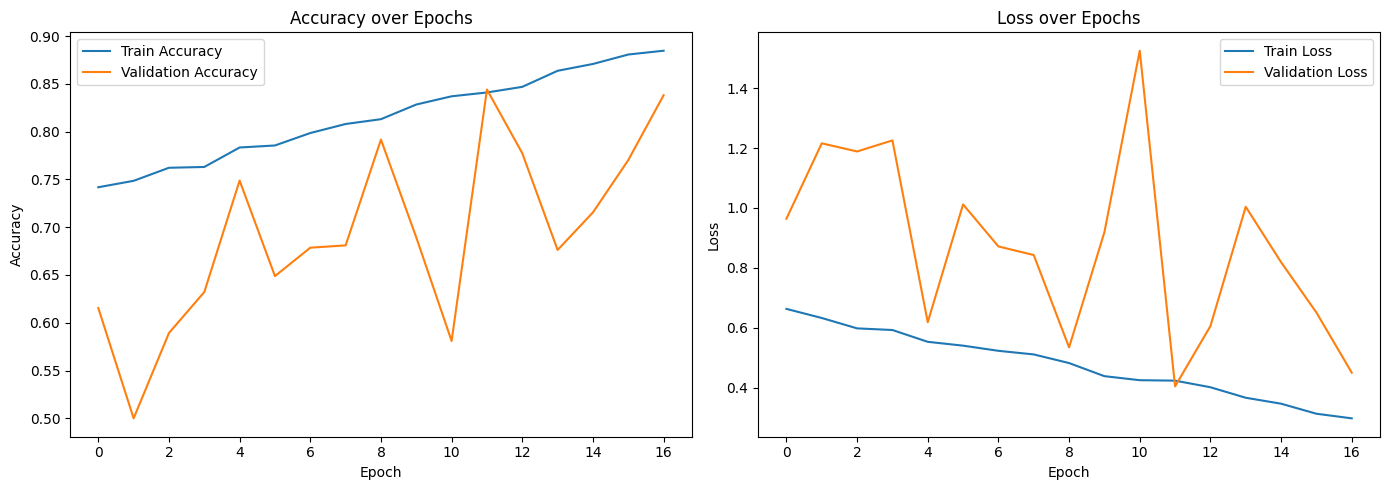

In [14]:
# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig(f'{PROJECT_PATH}/results/figures/cnn_scratch_training_history.png', dpi=150)
plt.show()

In [15]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7681 - loss: 0.8121
Test Accuracy: 0.7681
Test Loss: 0.8121


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


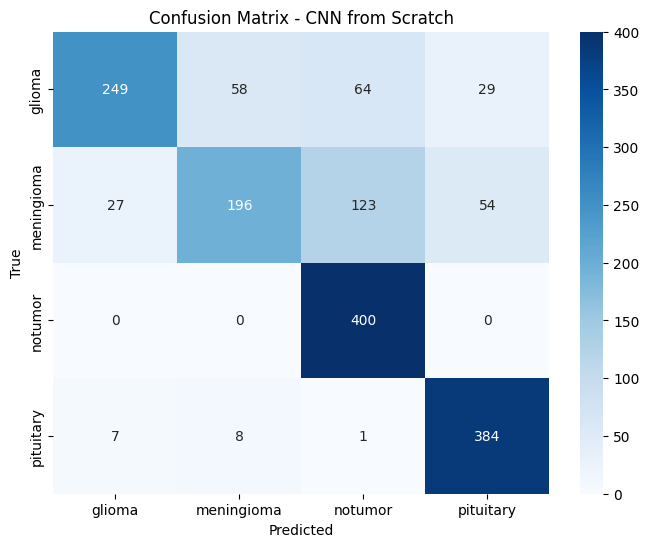

              precision    recall  f1-score   support

      glioma       0.88      0.62      0.73       400
  meningioma       0.75      0.49      0.59       400
     notumor       0.68      1.00      0.81       400
   pituitary       0.82      0.96      0.89       400

    accuracy                           0.77      1600
   macro avg       0.78      0.77      0.75      1600
weighted avg       0.78      0.77      0.75      1600



In [16]:
# Generate predictions and confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - CNN from Scratch')
plt.savefig(f'{PROJECT_PATH}/results/figures/cnn_scratch_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [17]:
# Save classification report and metrics as files
import json

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

with open(f'{PROJECT_PATH}/results/cnn_scratch_classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=4)

cnn_scratch_summary = {
    'model': 'CNN from Scratch',
    'total_params': 454660,
    'epochs_trained': 17,
    'early_stopped': True,
    'best_val_accuracy': 0.8440,
    'test_accuracy': 0.7681,
    'test_loss': 0.8121
}

with open(f'{PROJECT_PATH}/results/cnn_scratch_summary.json', 'w') as f:
    json.dump(cnn_scratch_summary, f, indent=4)

print("Results saved successfully.")

Results saved successfully.


In [18]:
# Step 16: Write analysis notes to a markdown file
analysis_notes = """# CNN From Scratch - Analysis Notes

## Architecture Summary
- 4 Conv blocks (32 -> 64 -> 128 -> 256 filters), 3x3 kernels
- GlobalAveragePooling2D instead of Flatten (reduced params from 3.6M to 454K)
- Dropout (0.5) before output layer for regularization
- Data Augmentation (rotation, zoom, contrast) applied only during training,
  restricted to medically plausible transformations (no flips, no large rotations)

## Training Results
- Trained for 17 epochs (Early Stopping triggered, patience=5 on val_loss)
- Best validation accuracy: 84.4% (epoch 12, restored via ModelCheckpoint)
- Final Test accuracy: 76.8%
- Test accuracy lower than best validation accuracy, and validation accuracy
  was highly unstable across epochs (fluctuations of up to 26% between consecutive epochs)

## Key Finding: Class Confusion Pattern
The confusion matrix revealed a specific, non-random error pattern rather than
uniform weak performance:

- notumor: 100% recall (perfect separation from tumor classes)
- pituitary: 96% recall (strong performance)
- glioma: 62% recall - significant confusion with notumor (64 misclassified)
- meningioma: 49% recall - severe confusion with notumor (123 misclassified, 31%)

## Interpretation
The model struggles specifically to distinguish glioma and meningioma from
notumor, while clearly separating pituitary and notumor from everything else.
This suggests:
1. Glioma and meningioma may share more subtle visual features that this
   model (454K parameters) is not capturing well
2. The model may be defaulting to "notumor" as a "safe" prediction when
   uncertain, which is a clinically risky failure mode (false negatives)
3. The validation set (840 images, ~210 per class) is small enough that
   per-epoch validation metrics are noisy and should not be over-interpreted
   in isolation; the test set (1600 images) result is more reliable

## Decision
This model is intentionally kept as the baseline for comparison with Transfer Learning models.
Further optimization is left as future work. The next step is Transfer Learning (ResNet50/EfficientNet) to
evaluate whether pretrained ImageNet features improve separation between
glioma and meningioma specifically.

## Potential Future Improvements (not implemented due to time)
- Reduce augmentation intensity (may be blurring fine-grained tumor features)
- Add class weights to penalize glioma/meningioma misclassification more heavily
- Increase model capacity in deeper layers
- Train for more epochs with a less aggressive early stopping patience
"""

with open(f'{PROJECT_PATH}/results/cnn_scratch_analysis.md', 'w') as f:
    f.write(analysis_notes)

print("Analysis notes saved.")

Analysis notes saved.
